# Xero: revenue and adjusted EBITDA
**FY23A–FY27G | NZ$ million | ASX: XRO / Yahoo ticker: XRO.AX**

Run the cells in order. The chart labels every revenue and adjusted EBITDA observation. FY27G uses management guidance **midpoints**, not the model's FY27 forecast or Yahoo analyst estimates.

The default is a shaded, stacked presentation: adjusted EBITDA is the lower boundary and revenue is the upper boundary. It stacks **adjusted EBITDA + (revenue minus adjusted EBITDA)** so the top remains revenue. It never stacks revenue plus EBITDA, which would double count. The residual is a mathematical difference, not a reported expense measure. Set `CHART_STYLE = "line"` for two unfilled lines.

**Data provenance:** FY23–FY26 figures are embedded from the supplied `Xero_DCF_Model(2).xlsx`, rows 34 and 38 of `3-Statement Model & Assumptions`. FY27 guidance is NZ$3,620–3,730m revenue and NZ$860–920m adjusted EBITDA, as recorded in the model and Xero's FY26 release. The notebook does not require that workbook to be present.

yfinance downloads Yahoo's annual income statement for a separate cross-check. Yahoo EBITDA is **not assumed to equal company-adjusted EBITDA**, and Yahoo's financial currency must be checked independently of the AUD share-price currency. Yahoo data never silently overwrites the chart.

Sources: [Xero financial information](https://www.xero.com/nz/investors/financial-information/), [FY26 market release](https://brandfolder.xero.com/NE531UQB/as/nvrr7wvj8fpp7rkgf9ww7w/Xero_FY26_ASX_Release), [yfinance documentation](https://ranaroussi.github.io/yfinance/reference/api/yfinance.Ticker.html).

In [1]:
# Run once if dependencies are missing (uncomment the next line):
# %pip install yfinance pandas numpy matplotlib
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
from IPython.display import display

TICKER = "XRO.AX"
RUN_YAHOO_CHECK = True  # Set False for offline use; the chart still works.
CHART_STYLE = "stacked"  # "stacked" or "line"
EXPORT_CHART = True
OUTPUT_DIR = Path("xero_chart_exports")


In [2]:
# Fixed company/model figures, all in NZ$ million.
revenue_guidance = (3620.0, 3730.0)
ebitda_guidance = (860.0, 920.0)
df = pd.DataFrame({
    "Period": ["FY23A", "FY24A", "FY25A", "FY26A", "FY27G"],
    "Revenue_NZD_m": [1399.884, 1713.767, 2102.652, 2753.081,
                       sum(revenue_guidance) / 2],
    "Adj_EBITDA_NZD_m": [301.689, 526.545, 641.814, 757.352,
                          sum(ebitda_guidance) / 2],
    "Basis": ["Actual", "Actual", "Actual", "Actual", "Guidance midpoint"],
})
df["Adj_EBITDA_margin_pct"] = 100 * df.Adj_EBITDA_NZD_m / df.Revenue_NZD_m
assert df.Period.is_unique and len(df) == 5
assert (df.Revenue_NZD_m >= df.Adj_EBITDA_NZD_m).all()
display(df.round({"Revenue_NZD_m": 1, "Adj_EBITDA_NZD_m": 1,
                  "Adj_EBITDA_margin_pct": 1}))


,Period,Revenue_NZD_m,Adj_EBITDA_NZD_m,Basis,Adj_EBITDA_margin_pct
0,FY23A,1399.9,301.7,Actual,21.6
1,FY24A,1713.8,526.5,Actual,30.7
2,FY25A,2102.7,641.8,Actual,30.5
3,FY26A,2753.1,757.4,Actual,27.5
4,FY27G,3675.0,890.0,Guidance midpoint,24.2


In [3]:
# Yahoo Finance cross-check: no substitutions or guessed currency conversions.
yahoo_statement = pd.DataFrame()
yahoo_comparison = pd.DataFrame()
if RUN_YAHOO_CHECK:
    try:
        import yfinance as yf
        ticker = yf.Ticker(TICKER)
        yahoo_statement = ticker.get_income_stmt(freq="yearly")
        if yahoo_statement.empty:
            raise ValueError("Yahoo returned no annual financial statement.")
        try:
            info = ticker.get_info()
            financial_currency = info.get("financialCurrency", "Unknown")
        except Exception:
            financial_currency = "Unknown"
        print(f"Yahoo financial currency: {financial_currency}; chart currency: NZD.")
        audit = []
        for column in yahoo_statement.columns:
            date = pd.Timestamp(column)
            if date.month != 3 or date.day != 31:
                continue
            period = f"FY{date.year % 100:02d}A"
            match = df.loc[df.Period.eq(period)]
            if match.empty:
                continue
            revenue = yahoo_statement.at["TotalRevenue", column] if "TotalRevenue" in yahoo_statement.index else np.nan
            ebitda = yahoo_statement.at["EBITDA", column] if "EBITDA" in yahoo_statement.index else np.nan
            audit.append({"Period": period, "Yahoo_revenue_m": revenue / 1e6,
                          "Yahoo_EBITDA_m_NOT_adjusted": ebitda / 1e6,
                          "Chart_revenue_NZD_m": match.Revenue_NZD_m.iloc[0],
                          "Chart_adjusted_EBITDA_NZD_m": match.Adj_EBITDA_NZD_m.iloc[0],
                          "Yahoo_financial_currency": financial_currency})
        yahoo_comparison = pd.DataFrame(audit)
        display(yahoo_comparison)
        print("Compare only after checking currency, reporting scope and EBITDA definition.")
        print("Missing fiscal years are retained from the supplied model; FY27G is company guidance.")
    except Exception as exc:
        warnings.warn(f"Yahoo cross-check unavailable: {type(exc).__name__}: {exc}. The sourced chart still works.")
else:
    print("Yahoo cross-check skipped for offline execution.")


Yahoo financial currency: NZD; chart currency: NZD.


,Period,Yahoo_revenue_m,Yahoo_EBITDA_m_NOT_adjusted,Chart_revenue_NZD_m,Chart_adjusted_EBITDA_NZD_m,Yahoo_financial_currency
0,FY26A,2295.764676,741.016511,2753.081,757.352,NZD
1,FY25A,1910.806979,697.389131,2102.652,641.814,NZD
2,FY24A,1572.119072,510.979727,1713.767,526.545,NZD
3,FY23A,1310.384723,167.895722,1399.884,301.689,NZD


Compare only after checking currency, reporting scope and EBITDA definition.
Missing fiscal years are retained from the supplied model; FY27G is company guidance.


Chart and data exported to /Users/audreyshan/Desktop/stock pitch/FMAA_stockpitch_comp/xero_chart_exports


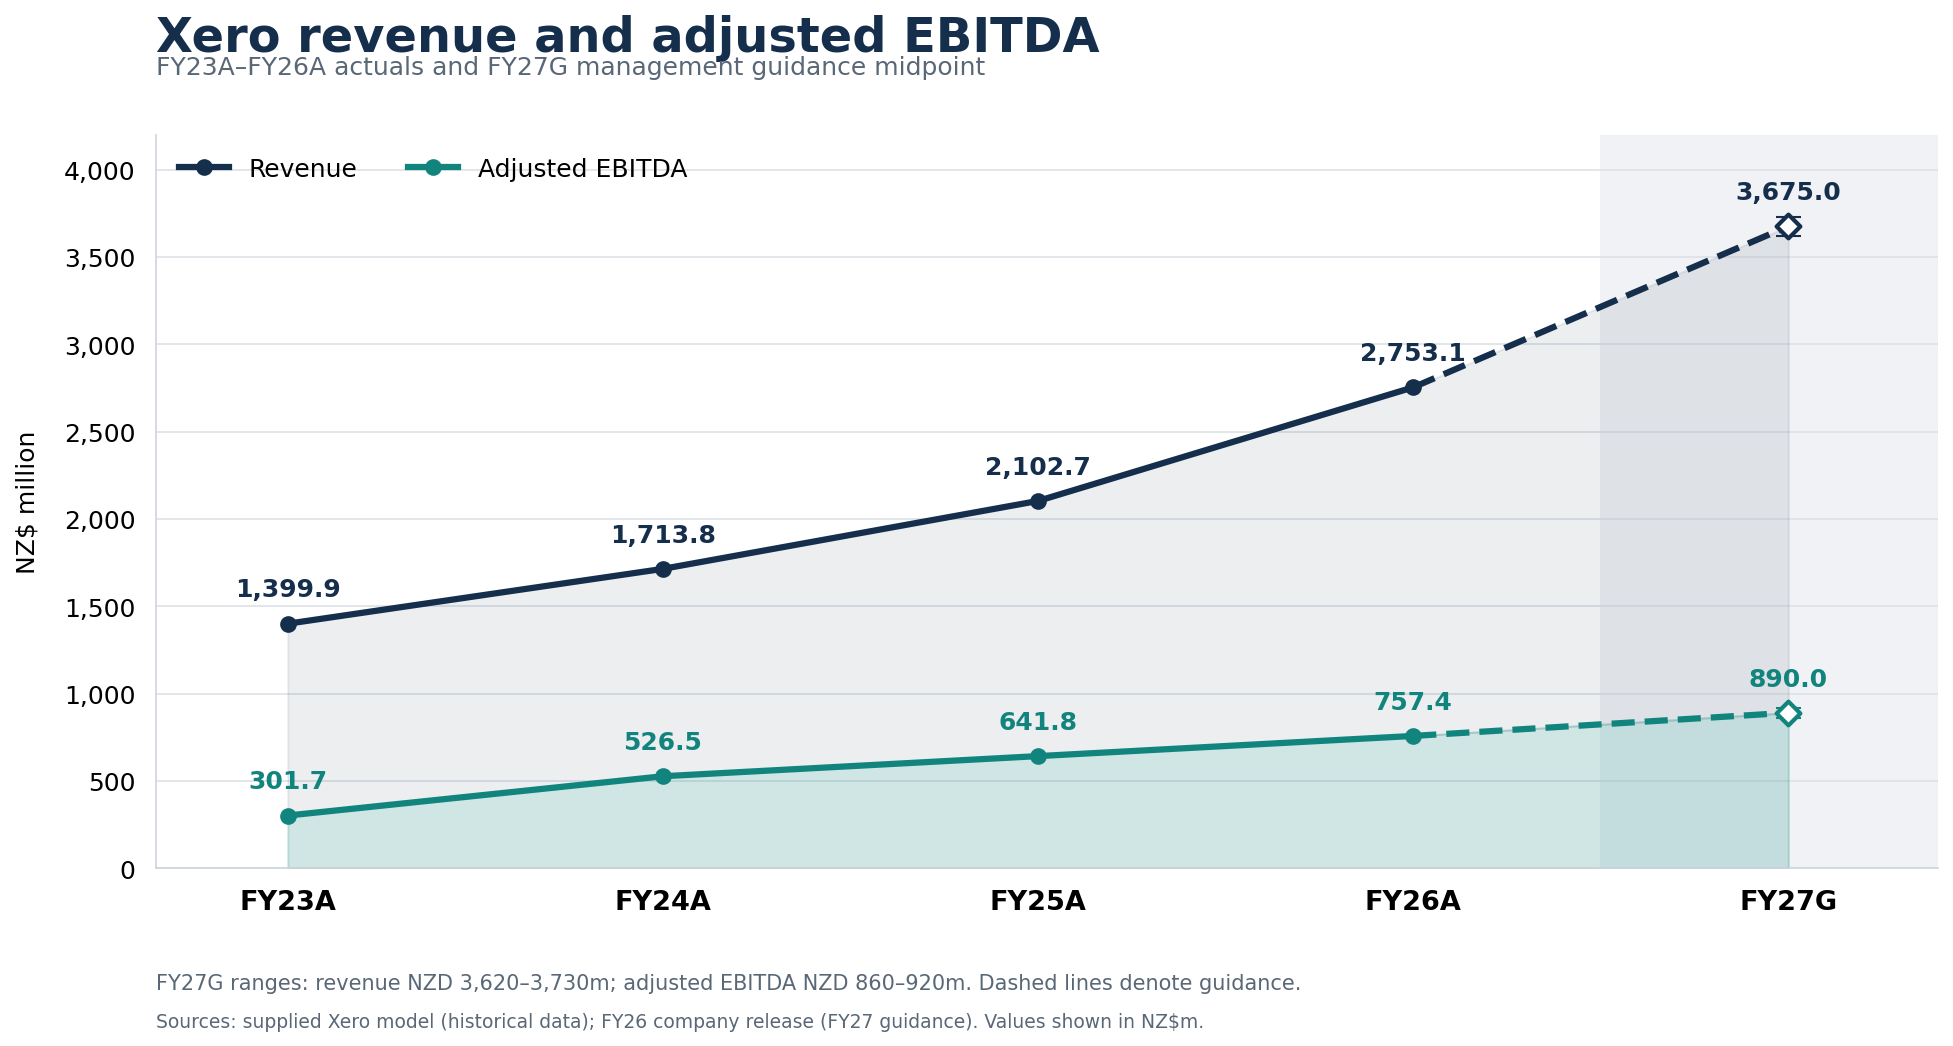

In [4]:
if CHART_STYLE not in {"stacked", "line"}:
    raise ValueError("CHART_STYLE must be 'stacked' or 'line'.")

x = np.arange(len(df))
revenue = df.Revenue_NZD_m.to_numpy()
ebitda = df.Adj_EBITDA_NZD_m.to_numpy()
navy, teal = "#142E4C", "#12847E"
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 12,
                     "axes.spines.top": False, "axes.spines.right": False})
fig, ax = plt.subplots(figsize=(13.5, 7.3), dpi=150)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.axvspan(3.5, 4.4, color="#F0F2F5", zorder=0)
if CHART_STYLE == "stacked":
    # Correct stacking: lower band EBITDA; upper band revenue less EBITDA.
    ax.fill_between(x, 0, ebitda, color=teal, alpha=.20, zorder=1)
    ax.fill_between(x, ebitda, revenue, color=navy, alpha=.08, zorder=1)

for values, color, label in [(revenue, navy, "Revenue"),
                              (ebitda, teal, "Adjusted EBITDA")]:
    ax.plot(x[:4], values[:4], color=color, lw=3, marker="o", ms=7,
            label=label, zorder=3)
    ax.plot(x[3:], values[3:], color=color, lw=3, linestyle="--", zorder=3)
    ax.scatter([4], [values[4]], s=65, marker="D", facecolor="white",
               edgecolor=color, linewidth=2, zorder=4)
    for i, value in enumerate(values):
        ax.annotate(f"{value:,.1f}", (i, value), xytext=(0, 13),
                    textcoords="offset points", ha="center", color=color,
                    fontsize=12, fontweight="bold", zorder=5)

# Range bars denote guidance intervals, not statistical confidence intervals.
for values, bounds, color in [(revenue, revenue_guidance, navy),
                              (ebitda, ebitda_guidance, teal)]:
    midpoint = values[-1]
    ax.errorbar(4, midpoint, yerr=[[midpoint-bounds[0]], [bounds[1]-midpoint]],
                fmt="none", color=color, capsize=6, lw=1.6, zorder=3)

ax.set_xticks(x, df.Period, fontsize=13, fontweight="bold")
ax.set_ylabel("NZ$ million", labelpad=12)
ax.set_ylim(0, 4200)
ax.set_xlim(-.35, 4.4)
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.grid(axis="y", color="#DDE2E7", lw=.8)
ax.set_axisbelow(True)
ax.spines["left"].set_color("#CDD4DB")
ax.spines["bottom"].set_color("#CDD4DB")
ax.tick_params(axis="both", length=0, pad=10)
fig.suptitle("Xero revenue and adjusted EBITDA", x=.08, ha="left",
             fontsize=23, fontweight="bold", color=navy, y=.96)
fig.text(.08, .905, "FY23A–FY26A actuals and FY27G management guidance midpoint",
         color="#596776", fontsize=12)
ax.legend(loc="upper left", frameon=False, ncol=2)
fig.text(.08, .07,
         "FY27G ranges: revenue NZD 3,620–3,730m; adjusted EBITDA NZD 860–920m. Dashed lines denote guidance.",
         fontsize=10, color="#596776")
fig.text(.08, .035,
         "Sources: supplied Xero model (historical data); FY26 company release (FY27 guidance). Values shown in NZ$m.",
         fontsize=9, color="#596776")
fig.subplots_adjust(left=.08, right=.96, bottom=.18, top=.85)
if EXPORT_CHART:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(OUTPUT_DIR / "Xero_revenue_adjusted_EBITDA.png", dpi=300, facecolor="white")
    fig.savefig(OUTPUT_DIR / "Xero_revenue_adjusted_EBITDA.svg", facecolor="white")
    df.to_csv(OUTPUT_DIR / "Xero_chart_data.csv", index=False)
    print(f"Chart and data exported to {OUTPUT_DIR.resolve()}")
plt.show()


## Interpretation
A = actual result; G = management guidance. Financial year ends 31 March. FY27G is the midpoint of a range, not a guaranteed result.

Revenue and EBITDA are on the **same currency and scale**. Adjusted EBITDA is not free cash flow, and the shaded difference between revenue and adjusted EBITDA is not a reported expense category. The chart does not add EBITDA on top of revenue. FY26 includes Melio's acquired contribution and is not an organic-only comparison.

For presentation use, keep the NZ$m unit and the guidance note. To refresh the figures, edit the embedded data and source notes after checking company disclosures; the Yahoo cross-check alone is insufficient to update adjusted EBITDA or guidance.